In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
from datetime import timedelta
import logging
import mysql

In [178]:
# Fetch data from database and return as a DataFrame
from shared.config import get_db_connection

def fetch_data(table_name, column_names='*', condition='1', sql=False):
    logging.info(f'Fetching data from {table_name}')
    try:
        # Get a connection to the database
        conn = get_db_connection()
        cursor = conn.cursor()
        # Fetch
        if sql:
            cursor.execute(sql)
        else:
            query = f"SELECT {column_names} FROM {table_name} WHERE {condition}"
            cursor.execute(query)
        # Fetch column names
        columns = [col[0] for col in cursor.description]
        # Fetch data
        data = cursor.fetchall()
        df = pd.DataFrame(data, columns=columns)
        return df
    except mysql.connector.Error as err:
        print(f"Error: {err}")
        return None
    finally:
        if 'conn' in locals() and conn.is_connected():
            cursor.close()
            conn.close()

In [179]:
def prepare_data(df, asset_class=None):
    """
    Prepare the DataFrame for the investment window analysis by ensuring proper data types and sorting.

    Args:
        df: DataFrame with 'TransactionDate', 'TransactionClass', and 'Available' columns
        asset_class: String to filter TransactionClass column (e.g., 'US Agencies')

    Returns:
        DataFrame: Cleaned and sorted DataFrame
    """

    # Define start and end dates
    today = pd.Timestamp('2025-09-01').normalize()
    # today = pd.Timestamp.now().normalize()
    end_date = today + pd.DateOffset(months=3)
    
    # 1. Filter the data within the date range
    data = df[(df['TransactionDate'] >= today) & (df['TransactionDate'] <= end_date)].copy()
    
    # 2. Filter by asset class if specified
    if asset_class is not None:
        # Check if asset_class exists in TransactionClass column
        if asset_class not in df['TransactionClass'].unique():
            raise ValueError(f"Asset class '{asset_class}' not found in data")
        data = data[data['TransactionClass'] == asset_class].copy()
        if data.empty:
            raise ValueError(f"No data found for asset class: {asset_class}")

    # Set the TransactionDate to datetime
    data['TransactionDate'] = pd.to_datetime(data['TransactionDate'])
    # Sort
    data = data.sort_values('TransactionDate').reset_index(drop=True)
    data['TransactionClass'] = asset_class if asset_class else 'Not Specified'
    return data[['TransactionDate', 'Available','TransactionClass']]

In [180]:
def find_start_date_and_global_minimum(df):
    """
    Identify the start date and global minimum balance information.

    Args:
        df: DataFrame with 'TransactionDate' and 'Availble' columns

    Returns:
        tuple: (start_date, global_min_balance, global_min_dates)
    """
    start_date = df['TransactionDate'].min()
    global_min_balance = df['Available'].min() # + 1000000  # Adding buffer of 1 million to the minimum available
    global_min_date = [df[df['Available'] == global_min_balance]['TransactionDate'].min()]

    return start_date, global_min_balance, global_min_date

In [181]:
def check_interval_validity(df_interval):
    """
    Check if an interval is valid according to the criteria:
    - The lowest balance in the interval occurs at the end date
    - If same low balance occurs on consecutive days, only capture the last occurrence

    Args:
        df_interval: DataFrame subset for the current interval

    Returns:
        tuple: (is_valid, min_balance, end_date)
    """
    if df_interval.empty:
        return False, None, None

    min_balance = df_interval['Available'].min()
    end_date = df_interval['TransactionDate'].iloc[-1]
    end_balance = df_interval['Available'].iloc[-1]

    # Check if the minimum balance occurs at the end date
    if end_balance != min_balance:
        return False, min_balance, end_date

    # Find all dates with the minimum balance
    min_balance_dates = df_interval[df_interval['Available'] == min_balance]['TransactionDate'].tolist()

    # If minimum balance occurs only at the end, it's valid
    if len(min_balance_dates) == 1 and min_balance_dates[0] == end_date:
        return True, min_balance, end_date

    # If minimum balance occurs on multiple days, check if end_date is the last occurrence
    if end_date == max(min_balance_dates):
        return True, min_balance, end_date

    return False, min_balance, end_date


In [182]:
def find_lowest_balance_intervals(df, asset_class=None):
    """
    Find all valid intervals where new lowest balances are set.

    Args:
        df: DataFrame with 'TransactionDate', 'TransactionClass', and 'Available' columns
        asset_class: String to filter TransactionClass column (e.g., 'US Agencies')

    Returns:
        list: List of dictionaries containing interval information
    """
    # Prepare data
    data = prepare_data(df, asset_class)

    # Print filtering information
    if asset_class:
        print(f"Filtering data for asset class: {asset_class}")
        print(f"Records found: {len(data)}")
        print()

    # Get basic information
    start_date, global_min_balance, global_min_dates = find_start_date_and_global_minimum(data)

    print(f"Start date: {start_date.date()}")
    print(f"Global minimum balance: ${global_min_balance:,.2f}")
    print(f"Global minimum occurs on: {[d.date() for d in global_min_dates]}")
    print()

    valid_intervals = []
    current_lowest_balance = float('inf')

    # Get unique dates for iteration
    unique_dates = sorted(data['TransactionDate'].unique())
    start_idx = 0  # Index of start_date in unique_dates

    # Iterate through progressively larger intervals
    for end_idx in range(start_idx, len(unique_dates)):
        current_start_date = unique_dates[start_idx]
        current_end_date = unique_dates[end_idx]

        # Filter data for current interval
        mask = (data['TransactionDate'] >= current_start_date) & (data['TransactionDate'] <= current_end_date)
        df_interval = data[mask].copy()

        # Check if interval is valid
        is_valid, min_balance, end_date = check_interval_validity(df_interval)

        if is_valid and min_balance < current_lowest_balance:
            # This is a new lowest balance
            interval_info = {
                'start_date': current_start_date,
                'end_date': current_end_date,
                'balance': min_balance,
                'days_in_interval': (current_end_date - current_start_date).days + 1
            }

            valid_intervals.append(interval_info)
            current_lowest_balance = min_balance

            print(f"Valid interval found: {current_start_date.date()} to {current_end_date.date()}")
            print(f"  New lowest balance: ${min_balance:,.2f}")
            print(f"  Interval length: {interval_info['days_in_interval']} days")
            print()

    return valid_intervals

In [183]:
def create_results_dataframe(intervals):
    """
    Convert the list of intervals to a DataFrame for easy viewing.

    Args:
        intervals: List of interval dictionaries

    Returns:
        DataFrame: Results in tabular format
    """
    if not intervals:
        return pd.DataFrame(columns=['Start_Date', 'End_Date', 'Available', 'Days_in_Interval'])

    results_df = pd.DataFrame(intervals)
    results_df = results_df.rename(columns={
        'start_date': 'Start_Date',
        'end_date': 'End_Date',
        'balance': 'Available',
        'days_in_interval': 'Days_in_Interval'
    })

    return results_df

In [184]:
def analyze_balance_data(df, asset_class=None):
    """
    Main function to perform the complete balance analysis.

    Args:
        df: DataFrame with 'TransactionDate', 'TransactionClass', and 'Available' columns
        asset_class: String to filter TransactionClass column (e.g., 'US Agencies')

    Returns:
        DataFrame: Results showing valid intervals where new lowest balances are set
    """
    print("=== Balance Analysis ===")
    print()

    # Find valid intervals
    intervals = find_lowest_balance_intervals(df, asset_class)

    # Create results DataFrame
    results_df = create_results_dataframe(intervals)

    print("=== Final Results ===")
    if results_df.empty:
        print("No valid intervals found.")
    else:
        print(results_df.to_string(index=False))

    return results_df

In [185]:
# # Example usage:
# if __name__ == "__main__":

#     df = pd.DataFrame(sample_data)

#     # Run the analysis for all data
#     print("Analysis for all asset classes:")
#     results_all = analyze_balance_data(df)

#     print("\n" + "="*50 + "\n")

#     # Run the analysis filtered by asset class
#     print("Analysis filtered for 'US Agencies':")
#     results_filtered = analyze_balance_data(df, asset_class='US Agencies')

In [188]:
# DEBUG TEST CELL
#     analyze_balance_data() for running the asset class balances processing
# In prod we'll be interating over each asset class and process the investment windows one by one
asset_classes = ['Certificate of Deposit', 'Mutual Fund', 'Commercial Paper', 'Money Market', 'US Treasuries', 'US Agencies']
# STEP 1: Load the data
asset_index = 4
running_balances = pd.read_pickle('running_balances.pkl')
data = prepare_data(running_balances, asset_classes[asset_index])
print (asset_classes[asset_index],":\n")
print(data)

# Get the base information parameters)
start_date, global_min_balance, global_min_date = find_start_date_and_global_minimum(data)

print(f"Start date: {start_date.date()}")
print(f"Global minimum balance: ${global_min_balance:,.2f}")
print(f"Global minimum occurs on: {global_min_date}") # [d.date() for d in global_min_dates]
print()

valid_intervals = []
current_lowest_balance = float('inf') # Initialize with infinity

# Get unique dates for iteration
unique_dates = sorted(data['TransactionDate'].unique())
start_idx = 0  # Index of start_date in unique_dates

print("\nUnique dates in dataset:")
for date in unique_dates:
    print(date.strftime('%Y-%m-%d'))

# Find valid intervals
intervals = find_lowest_balance_intervals(data, asset_classes[asset_index])

# Pretty print the intervals with formatted values instead of print(intervals)
for i, interval in enumerate(intervals, 1):
    print(f"\nInterval {i}:")
    print(f"  Start Date: {interval['start_date'].strftime('%Y-%m-%d')}")
    print(f"  End Date: {interval['end_date'].strftime('%Y-%m-%d')}")
    print(f"  Balance: ${interval['balance']:,.2f}")
    print(f"  Days: {interval['days_in_interval']}")

# Create results DataFrame
results_df = create_results_dataframe(intervals)

print("Investment Windows")
if results_df.empty:
    print("No valid intervals found.")
else:
    print(results_df.to_string(index=False))


US Treasuries :

   TransactionDate    Available TransactionClass
0       2025-09-04  18780124.55    US Treasuries
1       2025-09-05  17860124.55    US Treasuries
2       2025-09-06  17860124.55    US Treasuries
3       2025-09-07  17860124.55    US Treasuries
4       2025-09-08  84634124.55    US Treasuries
..             ...          ...              ...
84      2025-11-27  42226124.55    US Treasuries
85      2025-11-28  39626124.55    US Treasuries
86      2025-11-29  39626124.55    US Treasuries
87      2025-11-30  39626124.55    US Treasuries
88      2025-12-01  39626124.55    US Treasuries

[89 rows x 3 columns]
Start date: 2025-09-04
Global minimum balance: $0.00
Global minimum occurs on: [Timestamp('2025-10-10 00:00:00')]


Unique dates in dataset:
2025-09-04
2025-09-05
2025-09-06
2025-09-07
2025-09-08
2025-09-09
2025-09-10
2025-09-11
2025-09-12
2025-09-13
2025-09-14
2025-09-15
2025-09-16
2025-09-17
2025-09-18
2025-09-19
2025-09-20
2025-09-21
2025-09-22
2025-09-23
2025-09-24


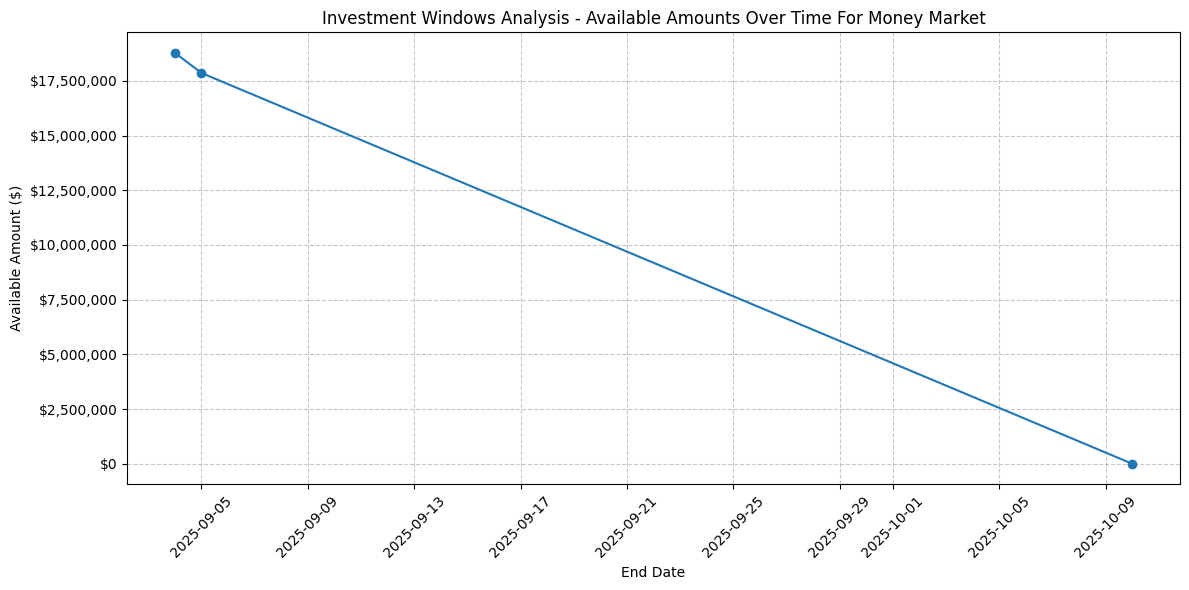

In [187]:
# Create a line plot using matplotlib
plt.figure(figsize=(12, 6))
plt.plot(results_df['End_Date'], results_df['Available'], marker='o')

# Format y-axis to show dollar amounts
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add labels and title
plt.xlabel('End Date')
plt.ylabel('Available Amount ($)')
plt.title('Investment Windows Analysis - Available Amounts Over Time For ' + asset_classes[asset_index])

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()